In [73]:
# Import the relevant modules
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

# Set a random seed for reproducibility of code
np.random.seed(42)
# Set seaborn plotting style
sns.set_style('dark')

In [74]:
# Import the data
df = pd.read_csv('stars_data.csv')

df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O
237,8829,537493.000000,1423.0000,-10.73,5,White,A
238,9235,404940.000000,1112.0000,-11.23,5,White,A


In [75]:
# Print out dataset dimensionality
print('The dataset has', df.shape[0], "data instances and", df.shape[1], 'attributes.')

The dataset has 240 data instances and 7 attributes.


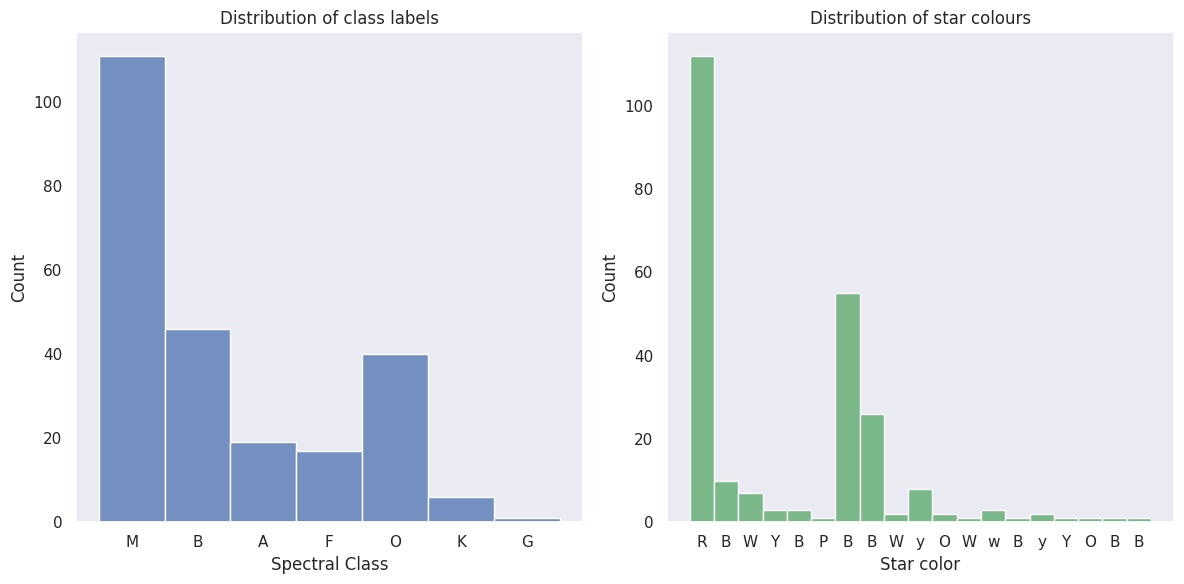

The number of items in class M is 111
The number of items in class B is 46
The number of items in class O is 40
The number of items in class A is 19
The number of items in class F is 17
The number of items in class K is 6
The number of items in class G is 1


In [76]:
# Plot some figures to visualise the distribution of the dataset
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax1 = sns.histplot(df['Spectral Class'], ax=axes[0], discrete=True, color='b')
ax2 = sns.histplot(df['Star color'], ax=axes[1], discrete=True, color='g')

axes[0].set_title('Distribution of class labels')
axes[1].set_title('Distribution of star colours')

# Set x-axis tick labels for the star colours so that they fit on the plot
star_color_labels = [label[0] for label in df['Star color'].unique()]
axes[1].set_xticks(range(len(star_color_labels)))
axes[1].set_xticklabels(star_color_labels)

plt.tight_layout()
plt.show()

# Print out the number of items in each class
class_counts = df['Spectral Class'].value_counts().to_dict()
for label, count in class_counts.items():
    print(f"The number of items in class {label} is {count}")

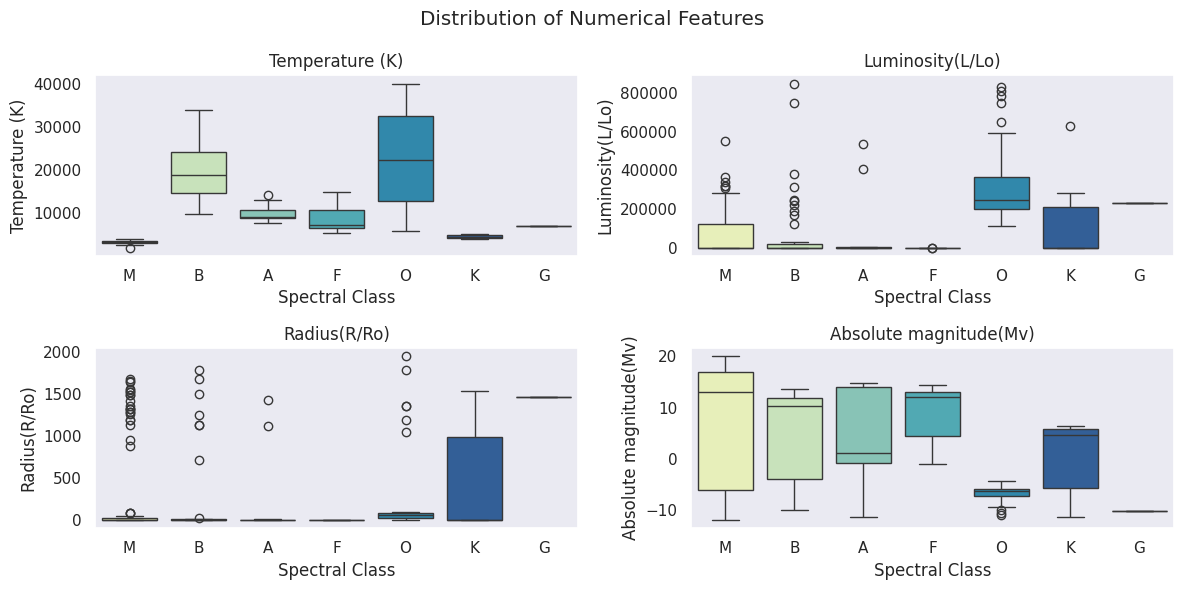

In [77]:
# Show the distribution of the continuous numerical features of the dataset with respect to class labels
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
fig.suptitle("Distribution of Numerical Features")

# Loop over continuous features in the dataset, keeping track of both index and feature
for i, feature in enumerate(df.columns[0:4]):
    ax = axes.flatten()[i]  # Set a variable for the i-th subplot
    sns.boxplot(x='Spectral Class', y=feature, data=df, ax=ax, hue='Spectral Class', palette='YlGnBu')
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [78]:
# Reduce/simplify the colours in the star color attribute for simpler encoding

# Create a colour mapping dictionary to reduce all colours to blue tint, red tint, yellow tint and white
color_mapping = {
    'Blue': 'Blue tint',
    'Blue ': 'Blue tint',
    'Blue White': 'Blue tint',
    'Blue white': 'Blue tint',
    'Blue white ': 'Blue tint',
    'Blue-White': 'Blue tint',
    'Blue-white': 'Blue tint',
    'Orange': 'Red tint',
    'Orange-Red': 'Red tint',
    'Pale yellow orange': 'Yellow tint',
    'Red': 'Red tint',
    'White': 'White',
    'White-Yellow': 'Yellow tint',
    'Whitish': 'White',
    'Yellowish': 'Yellow tint',
    'Yellowish White': 'Yellow tint',
    'white': 'White',
    'yellow-white': 'Yellow tint',
    'yellowish': 'Yellow tint'
}

# Apply the mapping to the 'star color' column
df['Simplified_color'] = df['Star color'].map(color_mapping)

# Remove the original star color column as it is no longer required
df.drop('Star color', axis=1, inplace=True)

# Move the 'Simplified_color' column to position index 5
cols = df.columns.tolist()
cols.insert(5, cols.pop(cols.index('Simplified_color')))
df = df[cols]
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Simplified_color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red tint,M
1,3042,0.000500,0.1542,16.60,0,Red tint,M
2,2600,0.000300,0.1020,18.70,0,Red tint,M
3,2800,0.000200,0.1600,16.65,0,Red tint,M
4,1939,0.000138,0.1030,20.06,0,Red tint,M


In [79]:
# Apply label encoding to the Simplified color column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Simplified_color'] = label_encoder.fit_transform(df['Simplified_color'])

In [80]:
# Get the list of classes (colors) and their corresponding labels
color_labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(color_labels)

{'Blue tint': 0, 'Red tint': 1, 'White': 2, 'Yellow tint': 3}


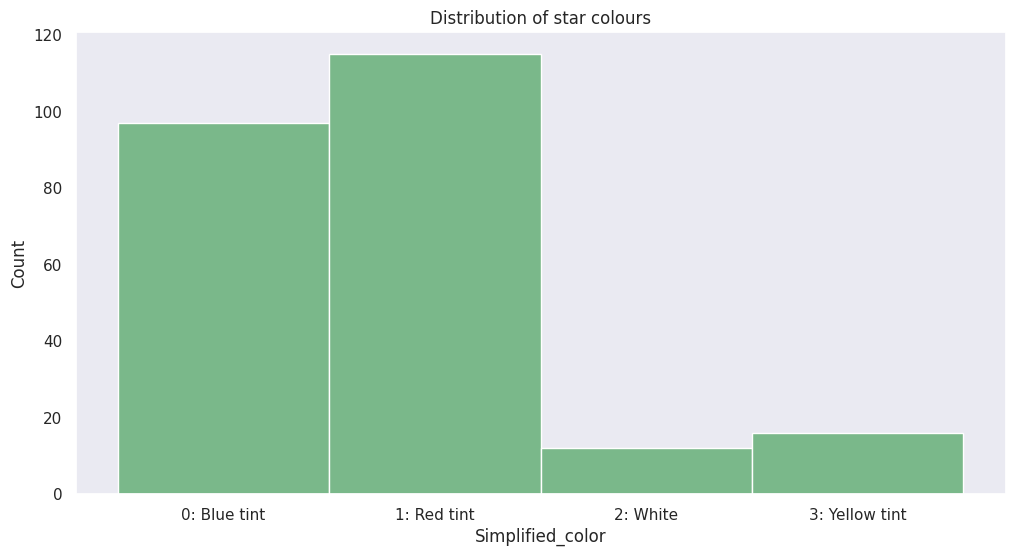

Colour 0: Blue tint - 97 instances
Colour 1: Red tint - 115 instances
Colour 2: White - 12 instances
Colour 3: Yellow tint - 16 instances


In [81]:
# Create a new histogram showing the distribution of star colours
plt.figure(figsize=(12, 6))
sns.histplot(df['Simplified_color'], discrete=True, color='g')

# Set title and x-axis labels
plt.title('Distribution of star colours')
plt.xticks(range(4), [f'{i}: {color}' for i, color in enumerate(label_encoder.classes_)])

# Show the plot
plt.show()

# Print the number of instances for each colour
for i, color in enumerate(label_encoder.classes_):
    count = (df['Simplified_color'] == i).sum()
    print(f'Colour {i}: {color} - {count} instances')

In [82]:
# Apply Gaussian normalisation to the continuous features of the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply Gaussian normalization to the first 4 columns
df.iloc[:, :4] = scaler.fit_transform(df.iloc[:, :4])

df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Simplified_color,Spectral Class
0,-0.779382,-0.598624,-0.459210,1.116745,0,1,M
1,-0.782110,-0.598624,-0.459241,1.162414,0,1,M
2,-0.828477,-0.598624,-0.459342,1.362213,0,1,M
3,-0.807496,-0.598624,-0.459229,1.167171,0,1,M
4,-0.897819,-0.598624,-0.459340,1.491607,0,1,M


<Axes: title={'center': 'Correlation Between Numerical Features'}>

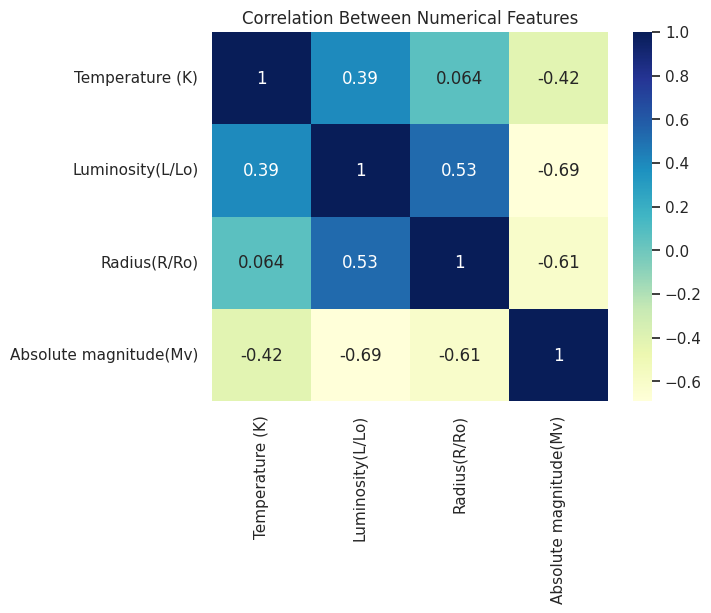

In [83]:
# Plot a heatmap showing the correlation between the numerical features
numerical_features = df.iloc[:, 0:4]

ax = plt.axes()
ax.set_title("Correlation Between Numerical Features")
sns.heatmap(numerical_features.corr(), annot=True, ax=ax, cmap='YlGnBu')

**Splitting the dataset, data augmentation on the training set, setting up scoring metrics, and cross validation criteria**

In [84]:
# Create a training and testing split of the dataset for supervised and unsupervised learning algorithms
# Import necessary sklearn modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Create feature data and class label subsets
X_data = df.iloc[:, :-1]
Y_data = df.iloc[:, -1]

# Identify rare class with only one sample and separate so the rest can be stratified in train/test split
class_counts = Y_data.value_counts()
rare_classes = class_counts[class_counts == 1].index
common_classes = class_counts[class_counts > 1].index

# Separate the data into rare and common classes
X_data_common = X_data[Y_data.isin(common_classes)]
Y_data_common = Y_data[Y_data.isin(common_classes)]

X_data_rare = X_data[Y_data.isin(rare_classes)]
Y_data_rare = Y_data[Y_data.isin(rare_classes)]

# Perform stratified split on the rest of the dataset to maintain the class proportions
X_train, X_test, Y_train, Y_test = train_test_split(X_data_common, Y_data_common, test_size=0.2, random_state=42, stratify=Y_data_common)

# Add the rare class back to the training set
X_train = pd.concat([X_train, X_data_rare], axis=0)
Y_train = pd.concat([Y_train, Y_data_rare], axis=0)

#Print dimensions of train and test sets split in the ratio 80:20
print('The number of samples in the training set originally is:', X_train.shape[0])
print('The number of samples in the test set originally is:', X_test.shape[0])

# Ensure that the one instance in class G is in the training set
# There is no point in being in the test set if no training data has been seen for class G
class_g_instance = Y_train[Y_train == 'G']
#Print to understand where the class g instance is
if len(class_g_instance) > 0:
    print(class_g_instance.index)
else:
    class_g_point = Y_test[Y_test == 'G']
    # Add the instance in class G to the training set (if needed)
    X_train = pd.concat([X_train, class_g_point])
    y_train = pd.concat([Y_train, class_g_point])
    # Remove the data point from the testing set (if needed)
    X_test = X_test.drop(class_g_point.index)
    Y_test = Y_test.drop(class_g_point.index)
    # Print index of class g once in training set
    class_g_instance = Y_train[Y_train == 'G']
    print(class_g_instance.index)

# Set up a scoring dictionary to store K-Fold cross-validation metrics. F1-score to be used primarily to deal with unbalanced dataset
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted')
}

# Set up 4 fold validation that maintains proportions of classes, and add a random state for reproducible results
kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

The number of samples in the training set originally is: 192
The number of samples in the test set originally is: 48
Index([118], dtype='int64')


In [85]:
from sklearn.utils import shuffle
# Apply some data augmentation for minority classes G and K
# List for minority classes
minority_classes = ['G', 'K']
# New dataframe for the augmented data
augmented_df = pd.DataFrame(columns=X_train.columns)
augmented_labels = []  # New list to store the augmented labels

# Find the spread of each numerical feature for class K
std_dev_dict = {}
for col in X_train.columns[0:4]:
    std_dev_dict[col] = np.std(X_train[Y_train == 'K'][col])

# Loop through each minority class
for cls in minority_classes:
    # Select the rows corresponding to the current minority class
    minority_class_idx = np.where(Y_train == cls)[0]
    minority_class_X_train = X_train.iloc[minority_class_idx]

    # Data augmentation on the minority class
    for i in range(5):  # Creates n x 5 instances to be added to the original dataframe
        # Randomly perturb the features based on standard deviation of class K
        perturbed_X_train = minority_class_X_train.copy()
        for col in X_train.columns[0:4]:
            perturbed_X_train[col] += np.random.normal(0, std_dev_dict[col], size=len(perturbed_X_train))

        # Add the perturbed data to the augmented dataframe
        augmented_df = pd.concat([augmented_df, perturbed_X_train], ignore_index=True)
        augmented_labels.extend([cls] * len(perturbed_X_train))  # Add the corresponding labels to the augmented labels list

# Add the original class G point back to the test set so there is at least one instance there
# Get the index of the original class G sample
original_G_idx = np.where(Y_train == 'G')[0][0]
# Get the original class G sample
original_G_sample = X_train.iloc[original_G_idx]

# Remove the original class G sample from the training set
X_train = X_train.drop(original_G_idx)
Y_train = Y_train.drop(original_G_idx)
# Add the original class G sample to the test set
X_test = pd.concat([X_test, original_G_sample.to_frame().T], ignore_index=True)
Y_test = pd.concat([Y_test, pd.Series(['G'])], ignore_index=True)

# Shuffle the augmented dataframe to randomize the order of the samples
augmented_df = shuffle(augmented_df)

# Append the augmented dataframe to the original training data
X_train = pd.concat([X_train, augmented_df], ignore_index=True)
Y_train = pd.concat([Y_train, pd.Series(augmented_labels)], ignore_index=True)  # Concatenate the original labels with the augmented labels
# Print shape of the augmented datasets
print(Y_train.shape)
print(X_train.shape)

# Print test dataset shape
print(Y_test.shape)
print(X_test.shape)

(221,)
(221, 6)
(49,)
(49, 6)


In [86]:
# G-sample
original_G_idx = np.where(Y_test == 'G')[0][0]
print(X_test.iloc[original_G_idx])
print(Y_test.iloc[original_G_idx])

Temperature (K)          -0.382634
Luminosity(L/Lo)          0.680291
Radius(R/Ro)              2.383058
Absolute magnitude(Mv)   -1.375037
Star type                 5.000000
Simplified_color          1.000000
Name: 48, dtype: float64
G


**Supervised Learning - Gaussian Naive Bayes**

In [87]:
from sklearn.naive_bayes import GaussianNB
# Initialise a default GNB classifier
clf_gnb = GaussianNB()
clf_gnb.fit(X_train, Y_train)

# Perform cross validation to obtain scoring metrics for an untuned model
results = cross_validate(clf_gnb, X_train, Y_train, scoring=scoring, cv=kfold)

# Find the means of the 4-fold validation metrics
mean_acc_base_gnb = np.mean(results['test_accuracy'])
mean_f1_base_gnb = np.mean(results['test_f1'])

# Print the accuracy and F1 scores for the base naive bayes classifier
print("Average Accuracy:", mean_acc_base_gnb)
print("Average F1:", mean_f1_base_gnb)
print(results['test_accuracy'])
print(results['test_f1'])

Average Accuracy: 0.8142045454545455
Average F1: 0.7868359181639141
[0.875      0.78181818 0.78181818 0.81818182]
[0.85219421 0.75267953 0.75341991 0.78905001]


In [88]:
# Tune a naive bayes classifier for best performance
from sklearn.model_selection import GridSearchCV

nb_classifier = GaussianNB()

# Very few tunable parameters, but var smoothing can be searched over using gridsearch
params_nb = {'var_smoothing': np.logspace(0,-9, num=100)}
gs_nb = GridSearchCV(estimator=nb_classifier,
                 param_grid=params_nb,
                 cv=kfold,
                 verbose=1,
                 scoring=scoring,
                 refit='f1') # Use F1-score for refitting given the unbalanced dataset

# Fit the gridsearch and print best var smoothing value
gs_nb.fit(X_train, Y_train)
print(gs_nb.best_params_)

# Create the best estimator classifier
tuned_clf_gnb = gs_nb.best_estimator_

# Perform cross validation
results = cross_validate(tuned_clf_gnb, X_train, Y_train, scoring=scoring, cv=kfold)

# Find the means of the 4-fold validation metrics
mean_acc_tuned_gnb = np.mean(results['test_accuracy'])
mean_f1_tuned_gnb = np.mean(results['test_f1'])

print("Average Accuracy:", mean_acc_tuned_gnb)
print("Average F1:", mean_f1_tuned_gnb)

Fitting 4 folds for each of 100 candidates, totalling 400 fits
{'var_smoothing': 8.111308307896872e-05}
Average Accuracy: 0.8459415584415585
Average F1: 0.8227293357373073


In [89]:
# Import evaluation modules
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

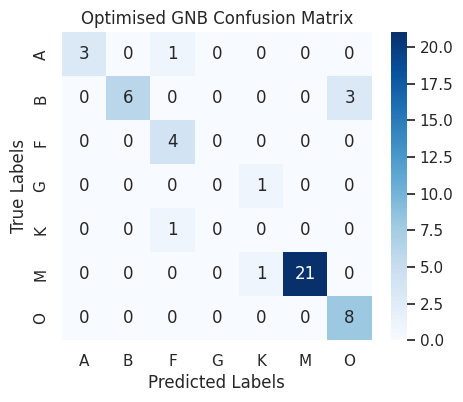

In [90]:
# Evaluate on test data
# Generate predictions on the testing set
y_pred = tuned_clf_gnb.predict(X_test)
classes = np.sort(Y_test.unique())
# Create the confusion matrix and display it
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Optimised GNB Confusion Matrix')
plt.show()

In [160]:
# Record scores and metrics, and show model performance
gnb_accuracy = accuracy_score(Y_test, y_pred)
print("GNB Accuracy:", gnb_accuracy)
gnb_f1 = f1_score(Y_test, y_pred, average='weighted')
print("GNB Weighted F1-Score:", gnb_f1)
gnb_macro = f1_score(Y_test, y_pred, average='macro')
print("GNB Macro F1-Score:", gnb_macro)

print(classification_report(Y_test, y_pred))

GNB Accuracy: 0.8571428571428571
GNB Weighted F1-Score: 0.8582405229970989
GNB Macro F1-Score: 0.6108560437638948
              precision    recall  f1-score   support

           A       1.00      0.75      0.86         4
           B       1.00      0.67      0.80         9
           F       0.67      1.00      0.80         4
           G       0.00      0.00      0.00         1
           K       0.00      0.00      0.00         1
           M       1.00      0.95      0.98        22
           O       0.73      1.00      0.84         8

    accuracy                           0.86        49
   macro avg       0.63      0.62      0.61        49
weighted avg       0.89      0.86      0.86        49



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Unsupervised Learning - K-means Clustering**

In [92]:
from sklearn.cluster import KMeans

# Create kmeans model with 7 clusters for each of the classes
kmeans = KMeans(n_clusters = 7, random_state = 42, n_init='auto')
kmeans.fit(X_train)

kmeans.labels_

array([1, 0, 2, 4, 3, 3, 6, 0, 0, 4, 1, 1, 2, 4, 2, 0, 2, 0, 0, 0, 2, 1,
       3, 3, 0, 0, 0, 5, 0, 4, 2, 1, 1, 5, 0, 0, 2, 0, 6, 0, 4, 0, 0, 0,
       0, 5, 0, 5, 1, 3, 4, 3, 0, 4, 6, 5, 3, 4, 1, 0, 1, 2, 0, 0, 3, 6,
       1, 1, 0, 3, 1, 0, 0, 6, 0, 4, 5, 3, 0, 0, 2, 2, 4, 0, 3, 4, 4, 0,
       2, 5, 0, 4, 1, 0, 4, 0, 1, 3, 2, 0, 5, 3, 0, 0, 2, 5, 3, 6, 0, 3,
       4, 3, 1, 4, 2, 1, 4, 0, 3, 0, 5, 0, 2, 2, 5, 5, 1, 5, 1, 6, 3, 0,
       0, 1, 0, 0, 0, 1, 1, 5, 3, 4, 5, 5, 0, 5, 0, 0, 1, 6, 0, 5, 5, 0,
       0, 5, 2, 4, 2, 0, 2, 6, 0, 5, 5, 1, 5, 0, 3, 1, 3, 0, 4, 2, 0, 0,
       4, 0, 3, 0, 2, 1, 3, 0, 0, 0, 3, 0, 5, 1, 2, 4, 4, 2, 1, 4, 4, 2,
       4, 2, 4, 5, 2, 4, 4, 2, 4, 2, 2, 4, 2, 2, 4, 4, 2, 4, 2, 2, 2, 4,
       4], dtype=int32)

In [93]:
# Evaluate the model on the training data
# Predict the clusters for the training data
train_clusters = kmeans.predict(X_train)

# Create a dictionary to hold the majority class label for each cluster
cluster_labels = {}

# Assign the label of the majority class for each cluster so that classification metrics can be computed
for i in range(kmeans.n_clusters):
    mask = train_clusters == i
    # Find classes and their counts assigned to the i-th cluster
    unique_classes, counts = np.unique(Y_train[mask], return_counts=True)
    majority_class_index = np.argmax(counts)
    # Determines majority class based on max count during each iteration
    majority_class = unique_classes[majority_class_index]
    # Assign majority class to be the value for the key of cluster label i
    cluster_labels[i] = majority_class
    print(unique_classes, counts)

# Map cluster labels to original class labels
train_predicted_labels = np.array([cluster_labels[cluster] for cluster in train_clusters])

['M'] [65]
['G' 'M' 'O'] [ 1  7 19]
['A' 'G' 'K' 'M' 'O'] [ 2  2 14 16  1]
['A' 'B'] [ 3 21]
['A' 'B' 'F' 'G' 'K'] [ 4  1 13  3 15]
['A' 'B' 'K' 'O'] [ 6 10  1  8]
['B' 'O'] [5 4]


In [94]:
# Print cluster labels and predicted labels mapping
print(cluster_labels)
print(train_predicted_labels)

{0: 'M', 1: 'O', 2: 'M', 3: 'B', 4: 'K', 5: 'B', 6: 'B'}
['O' 'M' 'M' 'K' 'B' 'B' 'B' 'M' 'M' 'K' 'O' 'O' 'M' 'K' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'O' 'B' 'B' 'M' 'M' 'M' 'B' 'M' 'K' 'M' 'O' 'O' 'B' 'M' 'M'
 'M' 'M' 'B' 'M' 'K' 'M' 'M' 'M' 'M' 'B' 'M' 'B' 'O' 'B' 'K' 'B' 'M' 'K'
 'B' 'B' 'B' 'K' 'O' 'M' 'O' 'M' 'M' 'M' 'B' 'B' 'O' 'O' 'M' 'B' 'O' 'M'
 'M' 'B' 'M' 'K' 'B' 'B' 'M' 'M' 'M' 'M' 'K' 'M' 'B' 'K' 'K' 'M' 'M' 'B'
 'M' 'K' 'O' 'M' 'K' 'M' 'O' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B'
 'M' 'B' 'K' 'B' 'O' 'K' 'M' 'O' 'K' 'M' 'B' 'M' 'B' 'M' 'M' 'M' 'B' 'B'
 'O' 'B' 'O' 'B' 'B' 'M' 'M' 'O' 'M' 'M' 'M' 'O' 'O' 'B' 'B' 'K' 'B' 'B'
 'M' 'B' 'M' 'M' 'O' 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'M' 'K' 'M' 'M' 'M' 'B'
 'M' 'B' 'B' 'O' 'B' 'M' 'B' 'O' 'B' 'M' 'K' 'M' 'M' 'M' 'K' 'M' 'B' 'M'
 'M' 'O' 'B' 'M' 'M' 'M' 'B' 'M' 'B' 'O' 'M' 'K' 'K' 'M' 'O' 'K' 'K' 'M'
 'K' 'M' 'K' 'B' 'M' 'K' 'K' 'M' 'K' 'M' 'M' 'K' 'M' 'M' 'K' 'K' 'M' 'K'
 'M' 'M' 'M' 'K' 'K']


In [95]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, train_predicted_labels)
print("Train Accuracy:", train_accuracy)

# Calculate F1 score
train_f1 = f1_score(Y_train, train_predicted_labels, average='weighted')
print("Train F1-score:", train_f1)

# Print classification report
print(classification_report(Y_train, train_predicted_labels))

Train Accuracy: 0.6832579185520362
Train F1-score: 0.6249702516972376
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        15
           B       0.62      0.97      0.76        37
           F       0.00      0.00      0.00        13
           G       0.00      0.00      0.00         6
           K       0.42      0.50      0.45        30
           M       0.81      0.92      0.86        88
           O       0.70      0.59      0.64        32

    accuracy                           0.68       221
   macro avg       0.36      0.43      0.39       221
weighted avg       0.58      0.68      0.62       221



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [161]:
# Evaluate the model on test data

# Predict the clusters for the test data
test_clusters = kmeans.predict(X_test)

# Map cluster labels to original class labels for the test data
test_predicted_labels = np.array([cluster_labels[cluster] for cluster in test_clusters])

test_acc_kmeans = accuracy_score(Y_test, test_predicted_labels)
test_f1_kmeans = f1_score(Y_test, test_predicted_labels, average='weighted')
kmeans_macro = f1_score(Y_test, test_predicted_labels, average='macro')
print("Test Accuracy:", test_acc_kmeans)
print("Test Weighted F1 Score:", test_f1_kmeans)
print("Test Macro F1 Score:", kmeans_macro)
print(classification_report(Y_test, test_predicted_labels))

Test Accuracy: 0.6122448979591837
Test Weighted F1 Score: 0.5670867907602603
Test Macro F1 Score: 0.29464250035678613
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         4
           B       0.44      0.78      0.56         9
           F       0.00      0.00      0.00         4
           G       0.00      0.00      0.00         1
           K       0.17      1.00      0.29         1
           M       0.91      0.91      0.91        22
           O       0.40      0.25      0.31         8

    accuracy                           0.61        49
   macro avg       0.27      0.42      0.29        49
weighted avg       0.56      0.61      0.57        49



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


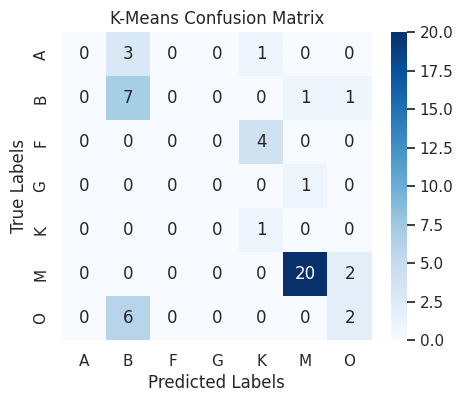

In [97]:
# Create the confusion matrix and display it
cm = confusion_matrix(Y_test, test_predicted_labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('K-Means Confusion Matrix')
plt.show()

**Neural Networks**

In [98]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
import torch.nn.functional as F

# Define device to train on, ideally GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [99]:
# Convert current train and test split data into tensors for use with MLP

# Apply label encoding for categorical class labels to convert to numbers
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

# Get the list of mapping dictionary of encoded numbers to spectral class
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(class_mapping)

{'A': 0, 'B': 1, 'F': 2, 'G': 3, 'K': 4, 'M': 5, 'O': 6}


In [100]:
# Convert Dataframe to numpy array first
X_train_array = X_train.to_numpy().astype(np.float32)
Y_train_array = Y_train_encoded
X_test_array = X_test.to_numpy().astype(np.float32)
Y_test_array = Y_test_encoded

# Stratified split of the training set into training and validation sets
X_train_split, X_val_split, Y_train_split, Y_val_split = train_test_split(
    X_train_array, Y_train_array, test_size=0.2, stratify=Y_train_array, random_state=42)

# Create tensors
X_train_tensor = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_split, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_split, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_split, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_array, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_array, dtype=torch.long)

# Create the train, validation and test datasets
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
validation_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# Create dataloaders with small batch size for small dataset
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [101]:
# Print dataloader item dimensions
for batch_idx, (data, target) in enumerate(train_loader):
    print("Data in Dataloader shape:", data.shape)
    print("Target in Dataloader shape:", target.shape)
    break

# Print batch sizes
print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Data in Dataloader shape: torch.Size([16, 6])
Target in Dataloader shape: torch.Size([16])
Train loader batches: 11
Validation loader batches: 3
Test loader batches: 4


**Define train and test function for neural networks**

In [102]:
def train(dataloader, model, loss_fn, optimizer, l1_lambda = 0, l2_lambda=0):
    '''
    Define a training function. Sets model into train mode and iterates through trianing data batches.
    For data in each batch, generate predictions from model. Perform L1 regularisation (if applicable)
    and calculate loss.
    Perform Backpropagation, apply weight changes as per optimiser parameters and flush gradient buffers

    dataloader --> an instance of 'DataLoader' that provides batches of data from the dataset. The dataset is wrapped in a 'Dataset' object that 'DataLoader' iterates over
    model --> neural network to be trained, an instance of NeuralNetwork class of object
    loss_fn --> loss function used to evaluate how well the model is performing
    optimizer --> optimisation algorithm used to update model's weights, based on gradients of loss function
    '''

    #calculates the total number of samples in dataset, useful for keeping track of progress in training
    size = len(dataloader.dataset)
    #puts model (instance of NeuralNetwork class) in training mode
    model.train()
    #Iterates over dataloader, yields batches of X (input data) and y (output labels) data
    for batch, (X, y) in enumerate(dataloader):
        #Ensures data and labels are moved to correct device
        X, y = X.to(device), y.to(device)

        #Reset gradient buffers
        optimizer.zero_grad()

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        #L1 Regularisation
        if l1_lambda > 0:
            l1_reg = sum(torch.norm(param, p=1) for param in model.parameters())
            loss += l1_lambda * l1_reg


        # L2 Regularization (If not using built-in weight_decay)
        if l2_lambda > 0:
            l2_reg = sum(torch.norm(param, p=2) for param in model.parameters())
            loss += l2_lambda * l2_reg


        # Backpropagation
        loss.backward() # Conduct backprop, compute gradients of error with respect to parameters
        optimizer.step() # Apply gradient changes as per optimiser parameters

In [103]:
def test(dataloader, model, loss_fn):

    '''
    Define a testing function. Sets model into evaluation mode and iterates through testing data batches.
    For data in each batch, generate predictions from model. Compare against labels and calculate loss.
    Keep track of number of total loss and number of correct answers
    Return test_loss and accuracy.

    dataloader --> an instance of 'DataLoader' that provides batches of data from the test dataset.
    model --> neural network to be tested
    loss_fn --> loss function used to evaluate how well the model is performing/how bad errors are
    '''

    #Calculate total number of samples in dataset, useful for tracking progress
    size = len(dataloader.dataset)
    # Extracts number of batches in dataloader
    num_batches = len(dataloader)
    # Switches model into evaluation mode
    model.eval()
    #initialise variables to keep track of testing loss and number of correct answers
    test_loss, correct = 0, 0
    # function enters torch.no_grad() context --> turns off gradient comptuation, no need
    with torch.no_grad():
        # Iterates over dataloader, yields batches of X (input data) and y (output data)
        for X, y in dataloader:
            #Ensure data and labels are on same/correct device
            X, y = X.to(device), y.to(device)
            #Save model predictions
            pred = model(X)
            # .item() gets scalar value of the tensor, accumulates loss for each batch
            test_loss += loss_fn(pred, y).item()
            #Calculates number of correctly predicted labels
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    #Calculates the average loss over all batches
    test_loss /= num_batches
    #Calcualtes the accuracy of the model on the test dataset, divides number of correct/total number samples
    accuracy = correct / size
    #Logging - prints accuracy and average loss of the model
    #print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, accuracy

**MLP**

In [104]:
## Define neural network model
# We define a simple, two-layer multi-layer perceptron and forward propagation

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(6, 96),
            nn.ReLU(),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Linear(96, 7),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [105]:
# Instantiate the model
mlp_model = MLP()

# Setting up hyperparameters - chosen by previous knowledge of Neural Network training
learning_rate = 0.002 # Define learning rate
optimizer = torch.optim.SGD(mlp_model.parameters(),lr=learning_rate) # Define the optimizer with SGD and learning rate
criterion = nn.CrossEntropyLoss() # Cross entropy loss for classification task
epochs = 300 # Set epochs for training

In [106]:
# MODEL TRAINING AND TESTING LOOP

# Instantiate lists to keep track of model loss score and accuracy throughout training
mlp_train_losses1 = []
mlp_train_accuracies1 = []
mlp_val_losses1 = []
mlp_val_accuracies1 = []

# Ensure model is on correct device
model = mlp_model.to(device)

#Training loop. For a given number of epochs, iteratively train and test model
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, mlp_model, criterion, optimizer, l1_lambda=0.01)

    train_loss, train_accuracy = test(train_loader, model, criterion) # Training set metrics
    mlp_train_losses1.append(train_loss)
    mlp_train_accuracies1.append(train_accuracy)
    print(f"Training Loss: {train_loss}, Training Accuracy: {train_accuracy}")

    validation_loss, validation_accuracy = test(val_loader, model, criterion)
    mlp_val_losses1.append(validation_loss)
    mlp_val_accuracies1.append(validation_accuracy)
    print(f"Validation Loss: {validation_loss}, Validation Accuracy: {validation_accuracy}")

print("Done!")

Epoch 1
-------------------------------
Training Loss: 1.956149318001487, Training Accuracy: 0.30113636363636365
Validation Loss: 1.954735517501831, Validation Accuracy: 0.3333333333333333
Epoch 2
-------------------------------
Training Loss: 1.939927718856118, Training Accuracy: 0.3409090909090909
Validation Loss: 1.9398900667826335, Validation Accuracy: 0.37777777777777777
Epoch 3
-------------------------------
Training Loss: 1.9246517528187146, Training Accuracy: 0.4772727272727273
Validation Loss: 1.9259149233500164, Validation Accuracy: 0.4666666666666667
Epoch 4
-------------------------------
Training Loss: 1.910334045236761, Training Accuracy: 0.4375
Validation Loss: 1.9127538998921711, Validation Accuracy: 0.4444444444444444
Epoch 5
-------------------------------
Training Loss: 1.8967755057594993, Training Accuracy: 0.4431818181818182
Validation Loss: 1.9002200762430828, Validation Accuracy: 0.4444444444444444
Epoch 6
-------------------------------
Training Loss: 1.8837707

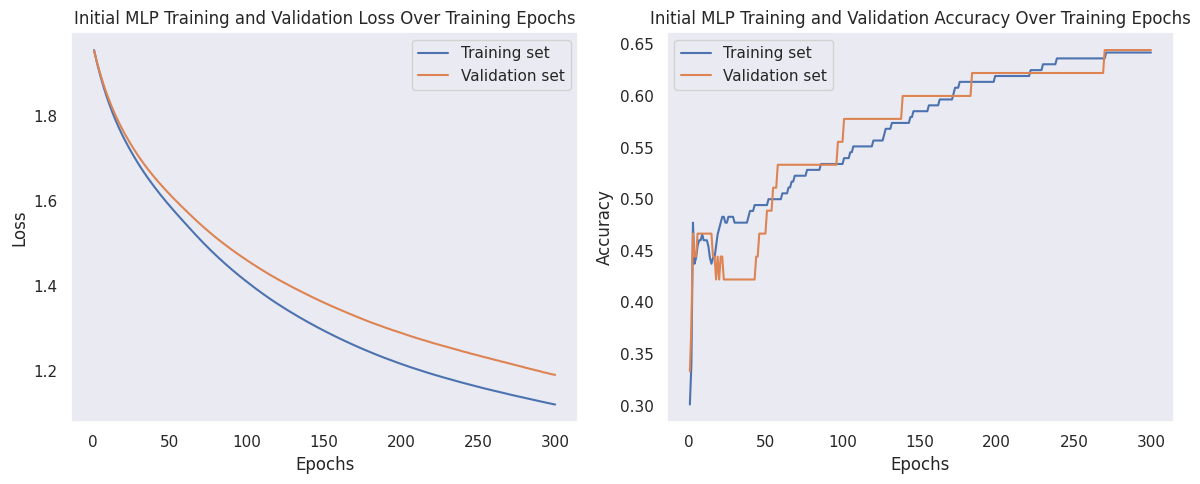

In [107]:
# Visualising Model Loss, Accuracy throughout performance. Validates model is learning appropriately

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs_axis = np.arange(1, epochs+1)

# Plot training and validation loss from epoch 1
ax1.plot(epochs_axis, mlp_train_losses1, label="Training set")
ax1.plot(epochs_axis, mlp_val_losses1, label="Validation set")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Initial MLP Training and Validation Loss Over Training Epochs")
ax1.legend()

# Plot training and validation accuracy
ax2.plot(epochs_axis, mlp_train_accuracies1, label="Training set")
ax2.plot(epochs_axis, mlp_val_accuracies1, label="Validation set")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Initial MLP Training and Validation Accuracy Over Training Epochs")
ax2.legend()

plt.tight_layout()
plt.show()

In [108]:
# Test Performance - Accuracy and Loss

test_loss, test_accuracy = test(test_loader, mlp_model, criterion)
print('MLP Test Accuracy: ', test_accuracy)
print('MLP Test Loss: ', test_loss)

MLP Test Accuracy:  0.673469387755102
MLP Test Loss:  1.551037460565567


In [109]:
# Modified Testing Function to Store predictions and ground truth values
def get_all_preds(model, loader):
    #instantiate lists to store predictions, labels
    all_preds = []
    all_labels = []
    # switch model to evaluation mode
    model.eval()

    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

labels, predictions = get_all_preds(model, test_loader)

In [110]:
# Calculate precision, recall, and F1-score
precision = precision_score(labels, predictions, average='weighted')  # 'weighted' for weighted mean per class
recall = recall_score(labels, predictions, average='weighted')
f1 = f1_score(labels, predictions, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.5327502429543245
Recall: 0.673469387755102
F1 Score: 0.5773614140961079


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Optimising MLP model with (hyper)parameter tuning**

In [111]:
# Install and import OpTuna
!pip install optuna
import optuna
from sklearn.model_selection import KFold
from torch.utils.data import Subset

In [112]:
#Modify Neural Network Class for more dynamic modulation of architecture, hyperparameters
class NeuralNetwork(nn.Module):
    def __init__(self, num_layers=3, hidden_size=96, activation='relu', use_batchnorm=False, use_dropout=False, dropout_rate=0.5, input_size = 6, output_size = 7):
      super(NeuralNetwork, self).__init__()
      self.flatten = nn.Flatten()
      layers = []

      # Activation function mapping
      activations = {
          'relu': nn.ReLU(),
          'leaky_relu': nn.LeakyReLU(),
          'elu': nn.ELU()
      }

      # First layer
      layers.append(nn.Linear(input_size, hidden_size))
      if use_batchnorm:
          layers.append(nn.BatchNorm1d(hidden_size))
      layers.append(activations[activation])
      if use_dropout:
          layers.append(nn.Dropout(dropout_rate))

      # Additional hidden layers
      for _ in range(num_layers - 1):
          layers.append(nn.Linear(hidden_size, hidden_size))
          if use_batchnorm:
              layers.append(nn.BatchNorm1d(hidden_size))
          layers.append(activations[activation])
          if use_dropout:
              layers.append(nn.Dropout(dropout_rate))


      # Output layer
      layers.append(nn.Linear(hidden_size, output_size))

      # Combine all layers into a sequential module
      self.linear_relu_stack = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [113]:
# Recreate fully joined training data with validation set included for k-fold cross validation
# Create tensors
X_train_tensor = torch.tensor(X_train_array, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_array, dtype=torch.long)

mlp_train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

In [114]:
## Define Optuna Objective Function

def objective(trial):
    # Hyperparameters - define hyperparameters and ranges/options to choose from
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
    hidden_size = trial.suggest_categorical('hidden_size', [48, 96, 192])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    activation = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam', 'RMSprop'])
    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
    use_dropout = trial.suggest_categorical('use_dropout', [True, False])
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5) if use_dropout else 0
    l1_lambda = trial.suggest_float('l1_lambda', 0, 0.001)  # L1 regularization
    l2_lambda = trial.suggest_float('l2_lambda', 0, 0.05)  # L2 regularization

    # Training and validation
    epochs = 200
    num_folds = 3
    criterion = nn.CrossEntropyLoss()

    # Creating K Folds Dataset
    dataset = mlp_train_dataset
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    accuracies = []

    # Generates indices to split data into training and validation subsets. Ensures each fold used only once
    for train_idx, val_idx in kf.split(range(len(dataset))):
        # Create training and validation subsets from original data
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        # Wrap training and validation datasets into DataLoaders for PyTorch iteration
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        # Instantiate a new model for each fold
        model = NeuralNetwork(num_layers, hidden_size, activation, use_batchnorm, use_dropout, dropout_rate).to(device)
        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Learning rate scheduler setup
        lr_scheduler_name = trial.suggest_categorical('lr_scheduler', ['StepLR', 'ExponentialLR'])
        if lr_scheduler_name == 'StepLR':
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        elif lr_scheduler_name == 'ExponentialLR':
            scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

        # Training loop set up
        for epoch in range(epochs):
            train(train_loader, model, criterion, optimizer, l1_lambda, l2_lambda)
            scheduler.step()

        # Test for model performance on validation set
        test_loss, accuracy = test(val_loader, model, criterion)

        # Test for pruning candidacy
        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # If not pruned, record accuracy
        accuracies.append(accuracy)

    # Objective: the average accuracy over all folds
    return np.mean(accuracies)

In [115]:
import time
start_time = time.time()

# Create optuna study. Run over 10 trials
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10)

# Log Best and Current Model Performance
print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

[I 2024-05-29 10:35:51,932] A new study created in memory with name: no-name-1049d765-9550-4180-b75d-4cb88c0aee41
<ipython-input-114-332908d7c427>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:493: UserWarning: The reported value is ignored because this `step` 199 is already reported.
  warnings.warn(
[I 2024-05-29 10:36:06,840] Trial 0 finished with value: 0.7325064790818215 and parameters: {'batch_size': 32, 'learning_rate': 0.07943738276210197, 'hidden_size': 96, 'num_layers': 2, 'activation': 'relu', 'optimizer': 'Adam', 'use_batchnorm': False, 'use_dropout': False, 'l1_lambda': 0.00015390653376166119, 'l2_lambda': 0.04163534288523888, 'lr_scheduler': 'ExponentialLR'}. Best is trial 0 with 

Best trial:
  Value: 0.8095766999876588
  Params: 
    batch_size: 32
    learning_rate: 0.05845899652547519
    hidden_size: 48
    num_layers: 2
    activation: relu
    optimizer: Adam
    use_batchnorm: True
    use_dropout: False
    l1_lambda: 0.0005440806422209217
    l2_lambda: 0.030105596102601353
    lr_scheduler: ExponentialLR
Elapsed time: 187.4416766166687 seconds


In [116]:
# Save best model for future reference/use
from google.colab import drive
drive.mount('/content/drive')

# Generate Best Model
best_model = NeuralNetwork(trial.params['num_layers'],
                           trial.params['hidden_size'],
                           trial.params['activation'],
                           trial.params['use_batchnorm'],
                           trial.params['use_dropout'],).to(device)

# Generate Best Optimiser
best_optimizer = getattr(torch.optim, trial.params['optimizer'])(best_model.parameters(), lr=trial.params['learning_rate'])

# Save the model's state dictionary
torch.save({
    'model_state_dict': best_model.state_dict(),
    'optimizer_state_dict': best_optimizer.state_dict(),
    'trial_params': trial.params
}, '/content/drive/My Drive/mlp_best_model_params_optimizer_comp534_assignment3.pth')

print(best_model)
print(best_optimizer)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=6, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=48, bias=True)
    (4): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=48, out_features=7, bias=True)
  )
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.05845899652547519
    maximize: False
    weight_decay: 0
)


In [117]:
# Train Optimised Model on original test/train data
epochs = 100

#Instantiate lists to keep track of model loss score and accuracy throughout training
mlp_train_losses2 = []
mlp_train_accuracies2 = []
mlp_val_losses2 = []
mlp_val_accuracies2 = []

# Ensure model is on correct device
best_mlp = best_model.to(device)

#Training loop. For a given number of epochs, iteratively train and test model
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, best_mlp, criterion, best_optimizer)

    train_loss, train_accuracy = test(train_loader, best_mlp, criterion) # Training set metrics
    mlp_train_losses2.append(train_loss)
    mlp_train_accuracies2.append(train_accuracy)
    print(f"Training Loss: {train_loss}, Training Accuracy: {train_accuracy}")

    validation_loss, validation_accuracy = test(val_loader, best_mlp, criterion)
    mlp_val_losses2.append(validation_loss)
    mlp_val_accuracies2.append(validation_accuracy)
    print(f"Validation Loss: {validation_loss}, Validation Accuracy: {validation_accuracy}")

print("Done!")

Epoch 1
-------------------------------
Training Loss: 0.7974697893316095, Training Accuracy: 0.7329545454545454
Validation Loss: 0.8389392296473185, Validation Accuracy: 0.7333333333333333
Epoch 2
-------------------------------
Training Loss: 0.6806695217436011, Training Accuracy: 0.7670454545454546
Validation Loss: 0.8770940701166788, Validation Accuracy: 0.7333333333333333
Epoch 3
-------------------------------
Training Loss: 0.6736047538844022, Training Accuracy: 0.6931818181818182
Validation Loss: 0.802539606889089, Validation Accuracy: 0.6888888888888889
Epoch 4
-------------------------------
Training Loss: 0.5070699074051597, Training Accuracy: 0.8125
Validation Loss: 0.6051860650380453, Validation Accuracy: 0.7777777777777778
Epoch 5
-------------------------------
Training Loss: 0.4510680667378686, Training Accuracy: 0.8068181818181818
Validation Loss: 0.5989040931065878, Validation Accuracy: 0.8444444444444444
Epoch 6
-------------------------------
Training Loss: 0.500020

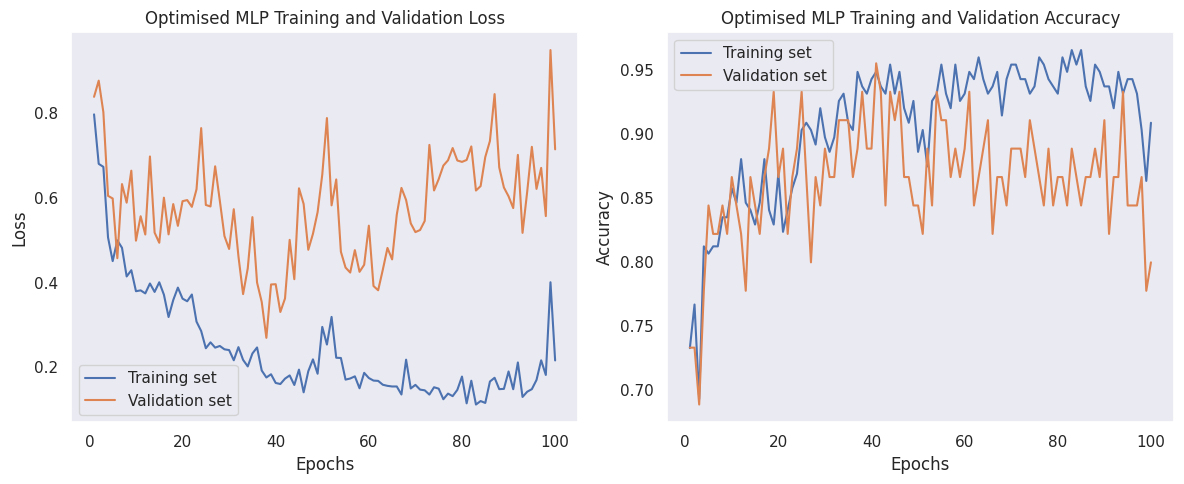

In [118]:
# Visualising Model Loss, Accuracy throughout performance. Validates model is learning appropriately

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs_axis = np.arange(1, epochs+1)

# Plot training and validation loss from epoch 1
ax1.plot(epochs_axis, mlp_train_losses2, label="Training set")
ax1.plot(epochs_axis, mlp_val_losses2, label="Validation set")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Optimised MLP Training and Validation Loss")
ax1.legend()

# Plot training and validation accuracy
ax2.plot(epochs_axis, mlp_train_accuracies2, label="Training set")
ax2.plot(epochs_axis, mlp_val_accuracies2, label="Validation set")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Optimised MLP Training and Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [119]:
# Run tests on the test data
mlp_test_loss2, mlp_test_accuracy2 = test(test_loader, best_mlp, criterion)
print('Optimised MLP Test Accuracy: ', mlp_test_accuracy2)
print('Optimised MLP Test Loss: ', mlp_test_loss2)

Optimised MLP Test Accuracy:  0.8367346938775511
Optimised MLP Test Loss:  0.6881609633564949


In [169]:
# Gather other metrics
labels, predictions = get_all_preds(best_mlp, test_loader)

# Calculate precision, recall, and F1-score
mlp_precision = precision_score(labels, predictions, average='weighted')  # 'weighted' for unweighted mean per class
mlp_recall = recall_score(labels, predictions, average='weighted')
mlp_f1 = f1_score(labels, predictions, average='weighted')
mlp_macro = f1_score(labels, predictions, average='macro')

print(f"Optimised MLP Precision: {mlp_precision}")
print(f"Optimised MLP Recall: {mlp_recall}")
print(f"Optimised MLP Weighted F1 Score: {mlp_f1}")
print(f"Optimised MLP Macro F1 Score: {mlp_macro}")

Optimised MLP Precision: 0.8561963916001184
Optimised MLP Recall: 0.8367346938775511
Optimised MLP Weighted F1 Score: 0.8333895964400797
Optimised MLP Macro F1 Score: 0.5856068743286789


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


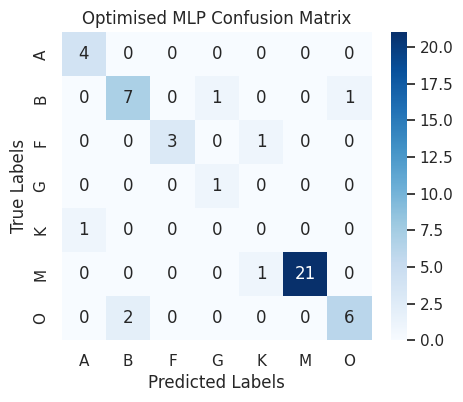

In [143]:
# Display the confusion matrix
mlp_cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Optimised MLP Confusion Matrix')
plt.show()

In [122]:
# Reverse class mapping dictionary so that values can be converted back to keys for classification report
reverse_class_map = {value: key for key, value in class_mapping.items()}
mlp_predictions = np.array([reverse_class_map[value] for value in predictions])

print(classification_report(Y_test, mlp_predictions))

              precision    recall  f1-score   support

           A       0.67      1.00      0.80         4
           B       0.80      0.89      0.84         9
           F       1.00      0.50      0.67         4
           G       0.00      0.00      0.00         1
           K       0.00      0.00      0.00         1
           M       0.91      0.95      0.93        22
           O       1.00      0.75      0.86         8

    accuracy                           0.84        49
   macro avg       0.63      0.58      0.59        49
weighted avg       0.86      0.84      0.83        49



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Convolutional Neural Network**

In [123]:
# Define a baseline model for CNN
class CNN(nn.Module):
  def __init__(self, hidden_size, conv1_chan_out, conv2_chan_out, dropout_p):
    super(CNN, self).__init__()

    # Create a sequential stack for the convolution, pooling and other feature extraction/manipulation
    self.features = nn.Sequential(
        nn.Conv1d(1, conv1_chan_out, kernel_size=3, stride=1, padding=1), # Kernel size, stride and padding selected to maintain the output dimensions of the image
        nn.BatchNorm1d(conv1_chan_out), # Normalise the 10 channels output by conv1
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2, stride=1),
        nn.Conv1d(conv1_chan_out, conv2_chan_out, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm1d(conv2_chan_out), # Normalise the 20 channels output by conv2
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2, stride=1) # Output size 10x4 (Disregarding batch size)
    )

    # Variable for input size to fully connected layers
    self.fc_inputsize = fc_inputsize

    # Sequential stack for the actual fully connected layers
    self.classifier = nn.Sequential(
        nn.Linear(self.fc_inputsize, hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout_p), # Dropout applies inactivation of random neurons at specified probability
        nn.Linear(hidden_size, 7)
    )

  # Define the operations required in the forward pass
  def forward(self, x):
    x = self.features(x)
    x = x.view(-1, self.fc_inputsize)  # Reshape the tensor to ensure that batch size is accounted for and the input is flattened
    x = self.classifier(x)
    return F.log_softmax(x, dim=1) # Softmax for probabilities in output layer

In [124]:
# Define hyperparameters

# Size of the input tensor
input_size = 1*6
# Hidden layer size
hidden_size = 128
# Number of channels output in convolution layer 1
conv1_chan_out = 10
#Number of channels output by convolution layer 2
conv2_chan_out = 20
# Size of input to fully connected layers
fc_inputsize = conv2_chan_out*4
# Dropout rate
dropout_p = 0.1

cnn_model = CNN(hidden_size, conv1_chan_out, conv2_chan_out, dropout_p)
cnn_model.to(device)

CNN(
  (features): Sequential(
    (0): Conv1d(1, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(10, 20, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)

In [125]:
# Define some hyperparameters for use in training

# Learning rate
lr = 0.001
# Optimizer
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=lr)
# Loss function
criterion = nn.CrossEntropyLoss()
# Number of epochs
num_epochs = 300
# Size of the training batch
batch_size = 16
# L2 regularisation strength parameter
l2_lambda = 0.01

In [126]:
# Prepare the dataloaders for CNN by adding channel dimension

# Create the train, validation and test datasets
cnn_train_dataset = TensorDataset(X_train_tensor.unsqueeze(1), Y_train_tensor)
cnn_validation_dataset = TensorDataset(X_val_tensor.unsqueeze(1), Y_val_tensor)
cnn_test_dataset = TensorDataset(X_test_tensor.unsqueeze(1), Y_test_tensor)

# Print data tensor dimensions
for data, label in cnn_train_dataset:
  print(f"Data tensor dimensions: {data.shape}")
  break

# Create dataloaders for training, validation and test sets
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=batch_size, shuffle=True)
cnn_val_loader = DataLoader(cnn_validation_dataset, batch_size=batch_size, shuffle=False)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=batch_size, shuffle=False)

# Print dataloader item dimensions
for batch_idx, (data, target) in enumerate(cnn_train_loader):
    print("Data in Dataloader shape:", data.shape)
    print("Target in Dataloader shape:", target.shape)
    break

# Print number of batches in each loader
print(f"The number of batches in the train loader is {len(cnn_train_loader)}")
print(f"The number of batches in the validation loader is {len(cnn_val_loader)}")
print(f"The number of batches in the test loader is {len(cnn_test_loader)}")

Data tensor dimensions: torch.Size([1, 6])
Data in Dataloader shape: torch.Size([16, 1, 6])
Target in Dataloader shape: torch.Size([16])
The number of batches in the train loader is 14
The number of batches in the validation loader is 3
The number of batches in the test loader is 4


In [127]:
# Run original CNN model training and evaluation
cnn_train_losses1 = []
cnn_train_accuracies1 = []
cnn_val_losses1 = []
cnn_val_accuracies1 = []

#Training loop. For a given number of epochs, iteratively train and test model
for t in range(num_epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(cnn_train_loader, cnn_model, criterion, optimizer, l2_lambda=l2_lambda)

    train_loss, train_accuracy = test(cnn_train_loader, cnn_model, criterion) # Training set metrics
    cnn_train_losses1.append(train_loss)
    cnn_train_accuracies1.append(train_accuracy)
    print(f"Training Loss: {train_loss}, Training Accuracy: {train_accuracy}")

    validation_loss, validation_accuracy = test(cnn_val_loader, cnn_model, criterion)
    cnn_val_losses1.append(validation_loss)
    cnn_val_accuracies1.append(validation_accuracy)
    print(f"Validation Loss: {validation_loss}, Validation Accuracy: {validation_accuracy}")

print("Done!")

Epoch 1
-------------------------------
Training Loss: 1.6599863086427962, Training Accuracy: 0.4479638009049774
Validation Loss: 1.664611021677653, Validation Accuracy: 0.4444444444444444
Epoch 2
-------------------------------
Training Loss: 1.3320205211639404, Training Accuracy: 0.5610859728506787
Validation Loss: 1.336501955986023, Validation Accuracy: 0.5333333333333333
Epoch 3
-------------------------------
Training Loss: 1.0819257753235954, Training Accuracy: 0.6425339366515838
Validation Loss: 1.0823924938837688, Validation Accuracy: 0.6222222222222222
Epoch 4
-------------------------------
Training Loss: 0.9035775491169521, Training Accuracy: 0.7239819004524887
Validation Loss: 0.8991056084632874, Validation Accuracy: 0.6666666666666666
Epoch 5
-------------------------------
Training Loss: 0.7782083749771118, Training Accuracy: 0.746606334841629
Validation Loss: 0.7511520584424337, Validation Accuracy: 0.7555555555555555
Epoch 6
-------------------------------
Training Loss

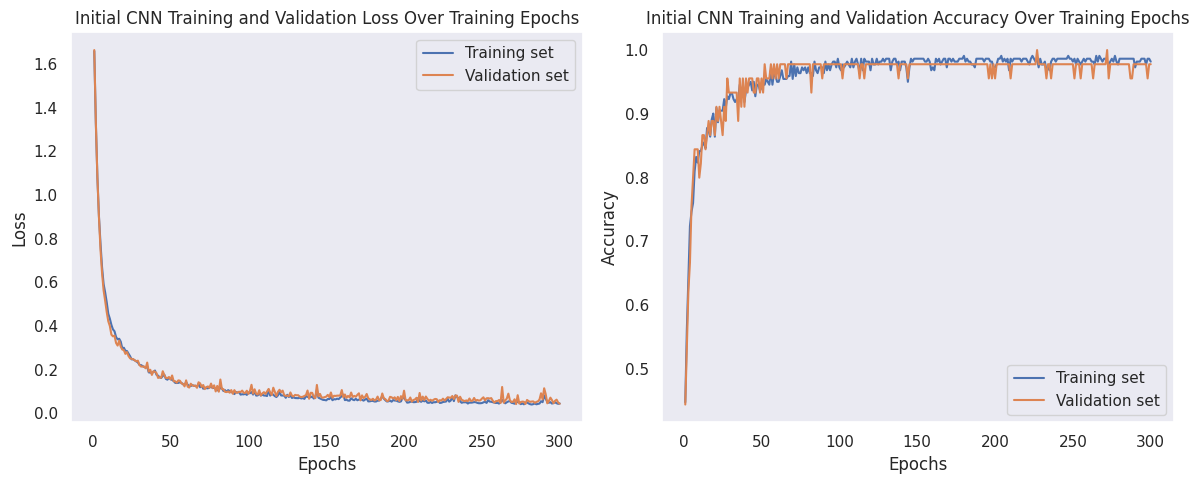

In [128]:
# Visualising Model Loss, Accuracy throughout performance. Validates model is learning appropriately

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs_axis = np.arange(1, num_epochs+1)

# Plot training and validation loss from epoch 1
ax1.plot(epochs_axis, cnn_train_losses1, label="Training set")
ax1.plot(epochs_axis, cnn_val_losses1, label="Validation set")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Initial CNN Training and Validation Loss Over Training Epochs")
ax1.legend()

# Plot training and validation accuracy
ax2.plot(epochs_axis, cnn_train_accuracies1, label="Training set")
ax2.plot(epochs_axis, cnn_val_accuracies1, label="Validation set")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Initial CNN Training and Validation Accuracy Over Training Epochs")
ax2.legend()

plt.tight_layout()
plt.show()

In [129]:
# Test Performance - Accuracy and Loss on the test data

test_accuracy, test_loss = test(cnn_test_loader, cnn_model, criterion)
print('CNN Test Accuracy: ', test_accuracy)
print('CNN Test Loss: ', test_loss)

CNN Test Accuracy:  0.7015894651412964
CNN Test Loss:  0.8571428571428571


In [130]:
# Generate Predictions
labels, predictions = get_all_preds(cnn_model, cnn_test_loader)

# Calculate precision, recall, and F1-score
precision = precision_score(labels, predictions, average='weighted')  # 'weighted' for weighted mean per class
recall = recall_score(labels, predictions, average='weighted')
f1 = f1_score(labels, predictions, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.8889212827988339
Recall: 0.8571428571428571
F1 Score: 0.8681462396697328


**Optimising CNN model with (hyper)parameter tuning**

In [131]:
# Modify CNN Class for more dynamic modulation of architecture, hyperparameters
class CNN(nn.Module):
  def __init__(self, num_hidden_layers=0, hidden_size=512, num_conv_layers=2, activation='relu', base_chanout_size=8, dropout_p=0.2, use_batchnorm=False, use_dropout=False):
    super(CNN, self).__init__()
    # Lists are created for adding convolutional layers and fully connected layers during the hyperparameter search process
    fc_layers = []
    conv_layers = []
    # Lists for storing output channels of each convolution layer
    conv_channels = [base_chanout_size]
    # Variables for image side length and output size corresponding to number of classes
    image_side = 6
    output_size = 7

    # Activation function mapping
    activations = {
        'relu': nn.ReLU(),
        'leaky_relu': nn.LeakyReLU(),
        'elu': nn.ELU()
    }

    # First convolution layer and activation, max pooling
    conv_layers.append(nn.Conv1d(1, base_chanout_size, kernel_size=3, stride=1, padding=1)) # Maintain kernel, stride and padding to maintain image dimensions
    if use_batchnorm:
        conv_layers.append(nn.BatchNorm1d(base_chanout_size))
    conv_layers.append(nn.ReLU()) # ReLU is widely used in convolution layers for dealing with non-linearity and need not be experimented with
    conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=1)) # Max pooling with kernel 2 and stride 2 halves the height and width dimensions each time

    # Subsequent convolution layers - The channel depth is doubled with each convolution
    for i in range(num_conv_layers - 1):
        conv_layers.append(nn.Conv1d(conv_channels[-1], conv_channels[-1]*2, kernel_size=3, stride=1, padding=1))
        conv_channels.append(conv_channels[-1] * 2) # Add the new out-channel size to the channels list
        if use_batchnorm:
            conv_layers.append(nn.BatchNorm1d(conv_channels[-1]))  # Batch normalisation applied to the new number of channels
        conv_layers.append(nn.ReLU())
        conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=1))

    # Combine all convolution and maxpooling layers into a sequential module
    self.features = nn.Sequential(*conv_layers)

    # Variable for input size to fully connected layers
    num_max_pool = num_conv_layers # Number of max pooling layers for use in calculating fully connected layers input size
    new_image_side = image_side - num_max_pool  # Divide side length by 2 for each max pooling layer
    data_dimensions = (conv_channels[-1] * new_image_side)  # Calculate the full size of the input to fully connected layers after self.features sequence
    self.fc_inputsize = int(round(data_dimensions))  # Convert this to an integer

    # First fully connected layer
    fc_layers.append(nn.Linear(self.fc_inputsize, hidden_size))
    # No need for batch normalisation here as already used in the convolution layers
    fc_layers.append(activations[activation])
    if use_dropout:
        fc_layers.append(nn.Dropout(dropout_p))

    # Subsequent hidden layer - Fixed to a size of 0 or 1 for the CNN model
    if num_hidden_layers == 1:
        fc_layers.append(nn.Linear(hidden_size, hidden_size))
        fc_layers.append(activations[activation])
        if use_dropout:
          fc_layers.append(nn.Dropout(dropout_p))

    # Output layer
    fc_layers.append(nn.Linear(hidden_size, output_size))

    # Combine all layers into a sequential module
    self.classifier = nn.Sequential(*fc_layers)

  # Define the operations required in the forward pass
  def forward(self, x):
    x = self.features(x)  # Apply convolution, ReLU and max pooling
    x = nn.Flatten()(x)  # Reshape the tensor to ensure that batch size is accounted for and the input is flattened
    x = self.classifier(x)  # Apply convolution output as an input to the fully connected layers
    return F.log_softmax(x, dim=1) # Softmax for probabilities in output layer


In [132]:
# No need for manual splitting of training and validation sets with KFold function available
X_train_tensor = torch.tensor(X_train_array, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_array, dtype=torch.long)

cnn_train_dataset = TensorDataset(X_train_tensor.unsqueeze(1), Y_train_tensor)

In [133]:
def objective(trial):
    # Define hyperparameters and ranges/options to choose from
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)  # Number of convolutional layers
    base_chanout_size = trial.suggest_categorical('base_chanout_size', [4, 8, 16, 32]) # Base output channel size for first conv layer
    num_hidden_layers = trial.suggest_categorical('num_hidden_layers', [0, 1])
    hidden_size = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    activation = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam', 'RMSprop'])
    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
    use_dropout = trial.suggest_categorical('use_dropout', [True, False])
    dropout_p = trial.suggest_uniform('dropout_p', 0.1, 0.5) if use_dropout else 0
    l1_lambda = trial.suggest_categorical('l1_lambda', [0, 0.001])  # L1 regularization
    l2_lambda = trial.suggest_categorical('l2_lambda', [0, 0.01])  # L2 regularization

    # Training and validation
    epochs = 200
    num_folds = 3
    criterion = nn.CrossEntropyLoss()

    # Create kfold cross validation
    dataset = cnn_train_dataset
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    accuracies = []

    # Generates indices to split data into training and validation subsets. Ensures each fold used only once
    for train_idx, val_idx in kf.split(range(len(dataset))):
        # Create training and validation subsets from original data
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        # Wrap training and validation datasets into DataLoaders for easy PyTorch iteration
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

        # Instantiate a new model for each fold
        model = CNN(num_hidden_layers, hidden_size, num_conv_layers, activation, base_chanout_size, dropout_p, use_batchnorm, use_dropout).to(device)
        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Learning rate scheduler setup
        lr_scheduler_name = trial.suggest_categorical('lr_scheduler', ['StepLR', 'ExponentialLR'])
        if lr_scheduler_name == 'StepLR':
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        elif lr_scheduler_name == 'ExponentialLR':
            scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

        # Training loop set up
        for epoch in range(epochs):
            train(cnn_train_loader, model, criterion, optimizer, l1_lambda, l2_lambda)
            scheduler.step()

        # Test for model performance on validation set
        val_loss, accuracy = test(val_loader, model, criterion)

        # Test for pruning candidacy
        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # If not pruned, record accuracy
        accuracies.append(accuracy)

    # Objective: the average accuracy over all folds
    return np.mean(accuracies)

In [134]:
import time
start_time = time.time()

# Create optuna study. Run over 20 trials
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10)

# Log Best and Current Model Performance
print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

[I 2024-05-29 10:39:50,382] A new study created in memory with name: no-name-71211a94-abd5-4eb0-835b-4c7770fe3c45
<ipython-input-133-484ada7e4197>:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
<ipython-input-133-484ada7e4197>:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_p = trial.suggest_uniform('dropout_p', 0.1, 0.5) if use_dropout else 0
/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:493: UserWarning: The reported value is ignored because this `step` 199 is already reported.
  warnings.warn(
[I 2024-05-29 10:40:41,249] Trial 0 finished with value: 0.6828335184499568 and parameters: {'b

Best trial:
  Value: 0.9092311489571764
  Params: 
    batch_size: 32
    learning_rate: 0.014542984920729677
    num_conv_layers: 2
    base_chanout_size: 16
    num_hidden_layers: 0
    hidden_size: 256
    activation: leaky_relu
    optimizer: Adam
    use_batchnorm: False
    use_dropout: True
    dropout_p: 0.1400258601920153
    l1_lambda: 0.001
    l2_lambda: 0
    lr_scheduler: StepLR
Elapsed time: 267.29693937301636 seconds


In [135]:
# Save best model for future use

# Generate Best Model
cnn_best_model = CNN(trial.params['num_hidden_layers'],
                           trial.params['hidden_size'],
                           trial.params['num_conv_layers'],
                           trial.params['activation'],
                           trial.params['base_chanout_size'],
                           trial.params['use_batchnorm'],
                           trial.params['use_dropout']).to(device)

# Generate Best Optimiser
cnn_best_optimizer = getattr(torch.optim, trial.params['optimizer'])(cnn_best_model.parameters(), lr=trial.params['learning_rate'])

# Generate best learning rate scheduler
if trial.params['lr_scheduler'] == 'StepLR':
    best_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
elif trial.params['lr_scheduler'] == 'ExponentialLR':
    best_lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

# Save the model and optimizer state dictionary, and the trial parameters
torch.save({
    'model_state_dict': cnn_best_model.state_dict(),
    'optimizer_state_dict': cnn_best_optimizer.state_dict(),
    'trial_params': trial.params
}, '/content/drive/My Drive/cnn_best_model_params_optimizer_comp534_assignment3.pth')

print(cnn_best_model)
print(cnn_best_optimizer)

CNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=7, bias=True)
  )
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.014542984920729677
    maximize: False
    weight_decay: 0
)


In [136]:
# Train Optimised Model on original test/train data
epochs = 100

#Instanitate lists to keep track of model loss score and accuracy throughout training
cnn_train_losses2 = []
cnn_train_accuracies2 = []
cnn_val_losses2 = []
cnn_val_accuracies2 = []

# Ensure model is on correct device
cnn_best_model = cnn_best_model.to(device)

#Training loop. For a given number of epochs, iteratively train and test model
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(cnn_train_loader, cnn_best_model, criterion, cnn_best_optimizer)

    train_loss, train_accuracy = test(cnn_train_loader, cnn_best_model, criterion) # Training set metrics
    cnn_train_losses2.append(train_loss)
    cnn_train_accuracies2.append(train_accuracy)
    print(f"Training Loss: {train_loss}, Training Accuracy: {train_accuracy}")

    validation_loss, validation_accuracy = test(cnn_val_loader, cnn_best_model, criterion)
    cnn_val_losses2.append(validation_loss)
    cnn_val_accuracies2.append(validation_accuracy)
    print(f"Validation Loss: {validation_loss}, Validation Accuracy: {validation_accuracy}")

print("Done!")

Epoch 1
-------------------------------
Training Loss: 1.3530257514544897, Training Accuracy: 0.5294117647058824
Validation Loss: 1.3096050421396892, Validation Accuracy: 0.5555555555555556
Epoch 2
-------------------------------
Training Loss: 0.7592313034193856, Training Accuracy: 0.7194570135746606
Validation Loss: 0.7363579670588175, Validation Accuracy: 0.7333333333333333
Epoch 3
-------------------------------
Training Loss: 0.6024545814309802, Training Accuracy: 0.7647058823529411
Validation Loss: 0.5060066978136698, Validation Accuracy: 0.8222222222222222
Epoch 4
-------------------------------
Training Loss: 0.4997301601937839, Training Accuracy: 0.7782805429864253
Validation Loss: 0.4726596275965373, Validation Accuracy: 0.8
Epoch 5
-------------------------------
Training Loss: 0.3578190409711429, Training Accuracy: 0.8868778280542986
Validation Loss: 0.29468051592508954, Validation Accuracy: 0.8888888888888888
Epoch 6
-------------------------------
Training Loss: 0.3759035

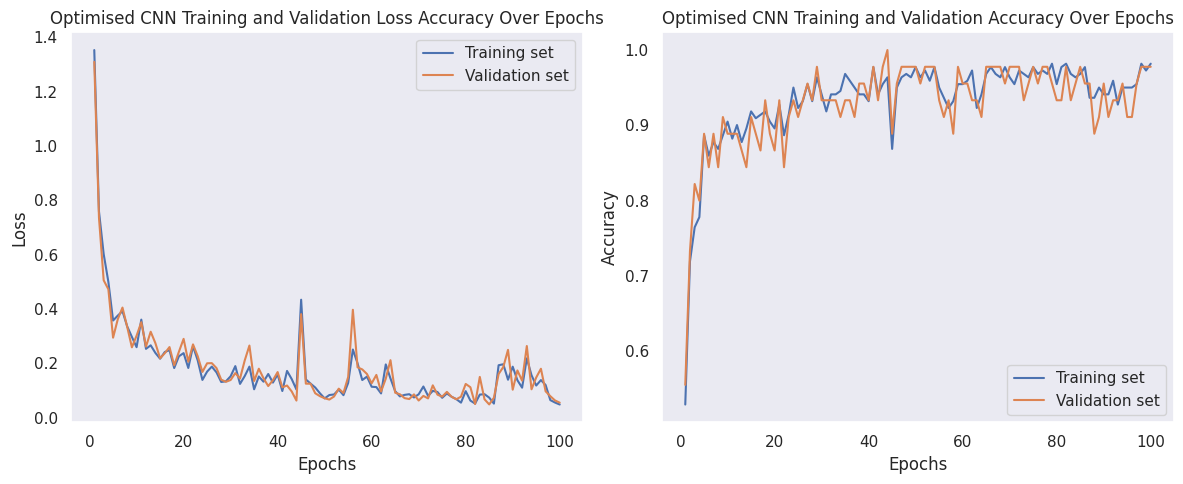

In [137]:
# Visualising Model Loss, Accuracy throughout performance. Validates model is learning appropriately

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs_axis = np.arange(1, epochs+1)

# Plot training and validation loss from epoch 1
ax1.plot(epochs_axis, cnn_train_losses2, label="Training set")
ax1.plot(epochs_axis, cnn_val_losses2, label="Validation set")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Optimised CNN Training and Validation Loss Accuracy Over Epochs")
ax1.legend()

# Plot training and validation accuracy
ax2.plot(epochs_axis, cnn_train_accuracies2, label="Training set")
ax2.plot(epochs_axis, cnn_val_accuracies2, label="Validation set")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Optimised CNN Training and Validation Accuracy Over Epochs")
ax2.legend()

plt.tight_layout()
plt.show()

In [138]:
print('Optimised CNN Validation Loss', cnn_val_losses2[-1])
print('Optimised CNN Training Loss', cnn_train_losses2[-1])

Optimised CNN Validation Loss 0.055503128096461296
Optimised CNN Training Loss 0.048728056967125406


In [139]:
# Run optimised CNN model on the test data
cnn_test_loss2, cnn_test_accuracy2 = test(cnn_test_loader, cnn_best_model, criterion)
print('Optimised CNN Test Accuracy: ', cnn_test_accuracy2)
print('Optimised CNN Test Loss: ', cnn_test_loss2)

Optimised CNN Test Accuracy:  0.8775510204081632
Optimised CNN Test Loss:  0.4370019268244505


In [165]:
# Generate Predictions on test data for best CNN model
cnn_labels, cnn_predictions = get_all_preds(cnn_best_model, cnn_test_loader)

In [166]:
# Calculate precision, recall, and F1-score
cnn_precision = precision_score(cnn_labels, cnn_predictions, average='weighted')  # 'weighted' for unweighted mean per class
cnn_recall = recall_score(cnn_labels, cnn_predictions, average='weighted')
cnn_f1 = f1_score(cnn_labels, cnn_predictions, average='weighted')
cnn_macro = f1_score(cnn_labels, cnn_predictions, average='macro')

print(f"Precision: {cnn_precision}")
print(f"Recall: {cnn_recall}")
print(f"Weighted F1 Score: {cnn_f1}")
print(f"Macro F1 Score: {cnn_macro}")

Precision: 0.8950437317784256
Recall: 0.8775510204081632
Weighted F1 Score: 0.8857142857142857
Macro F1 Score: 0.7903318903318902


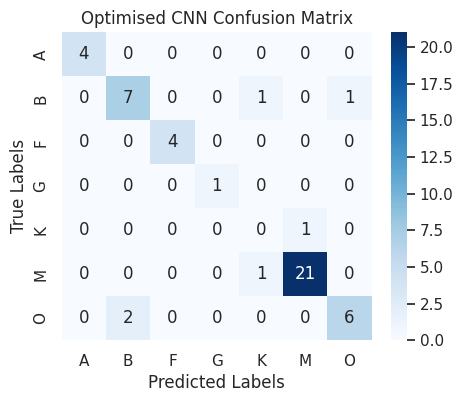

In [167]:
cnn_cm = confusion_matrix(cnn_labels, cnn_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Optimised CNN Confusion Matrix')
plt.show()

In [168]:
# Classification report for CNN
cnn_predictions = np.array([reverse_class_map[value] for value in cnn_predictions])

print(classification_report(Y_test, cnn_predictions))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       0.78      0.78      0.78         9
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         1
           K       0.00      0.00      0.00         1
           M       0.95      0.95      0.95        22
           O       0.86      0.75      0.80         8

    accuracy                           0.88        49
   macro avg       0.80      0.78      0.79        49
weighted avg       0.90      0.88      0.89        49



**Comparison of Model Performance**

In [171]:
# Performance metrics
model_names = ['Gaussian Naive Bayes', 'K-Means', 'MLP', 'CNN']
accuracies = [gnb_accuracy, test_acc_kmeans, mlp_test_accuracy2, cnn_test_accuracy2]
f1_scores = [gnb_f1, test_f1_kmeans, mlp_f1, cnn_f1]
macro_f1 = [gnb_macro, kmeans_macro, mlp_macro, cnn_macro]

# Create a DataFrame
data = {
    'Model': model_names,
    'Accuracy': accuracies,
    'Weighted F1': f1_scores,
    'Macro F1': macro_f1
}

df = pd.DataFrame(data)

In [172]:
df

,Model,Accuracy,Weighted F1,Macro F1
0,Gaussian Naive Bayes,0.857143,0.858241,0.610856
1,K-Means,0.612245,0.567087,0.294643
2,MLP,0.836735,0.833390,0.585607
3,CNN,0.877551,0.885714,0.790332


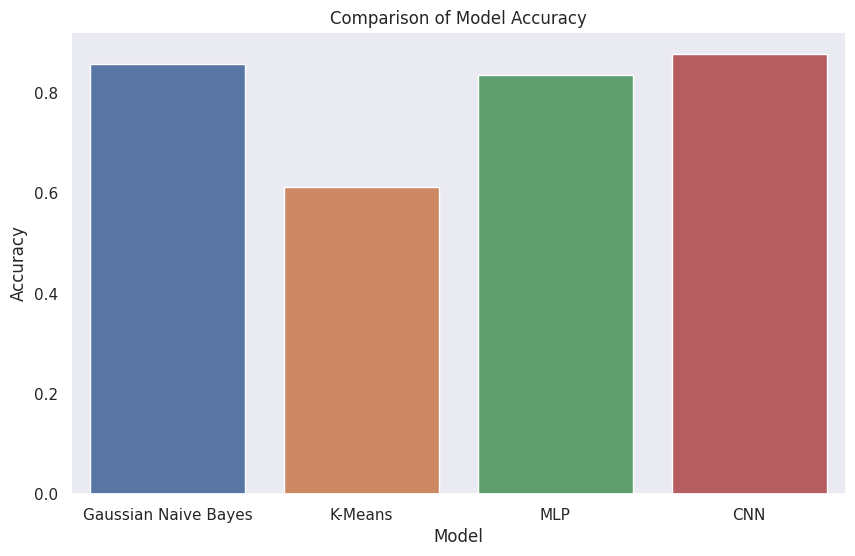

In [173]:
# Plot accuracies

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x='Model', y='Accuracy', hue='Model', data=df)

# Set plot title and labels
plt.title('Comparison of Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')

# Show the plot
plt.show()

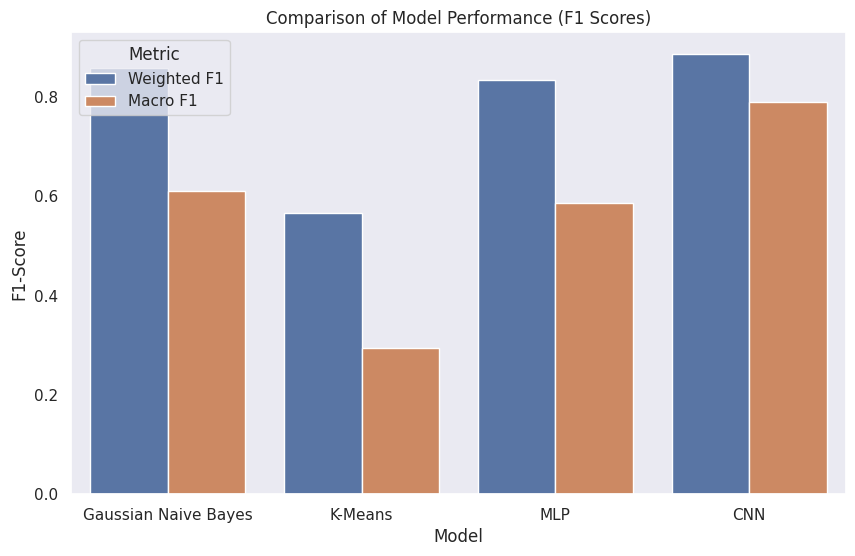

In [175]:
# Plot F1-scores
# Reshape the DataFrame to format appropriate for each model to have 2 bars
df_melted = df.melt(id_vars='Model', value_vars=['Weighted F1', 'Macro F1'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted)

# Set plot title and labels
plt.title('Comparison of Model Performance (F1 Scores)')
plt.xlabel('Model')
plt.ylabel('F1-Score')

# Show the plot
plt.show()